<a href="https://colab.research.google.com/github/hkubramese/ars-coregulation-cancer/blob/main/notebooks/01_feasibility_pilot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARS Co-regulation in Cancer — Step 1: Feasibility Pilot
## Do aminoacyl-tRNA synthetase (ARS) genes behave as a co-expression module in tumours?

**Project:** ARS co-regulation in cancer (bioRxiv preprint + GitHub repository)
**Notebook:** `01_feasibility_pilot.ipynb` — Version 1.0
**Cohort used in this pilot:** TCGA Lung Adenocarcinoma (LUAD), primary tumours only

### GOAL OF THIS NOTEBOOK
Before investing several months in a pan-cancer analysis, we test the core idea on **one cancer type** in a few hours. This notebook answers three questions:

1. Are cytoplasmic ARS genes more strongly correlated with each other than random genes with similar expression levels?
2. Does this correlation survive after we remove the effect of cell proliferation?
3. Is the ARS module score associated with an ATF4 activity signature that does **not** contain any ARS gene?

The answers decide the next step (see the decision table at the end of the notebook).

### Analytical expectation
Translation-related genes tend to rise together in fast-dividing tumours. Therefore we **expect** some positive correlation between ARS genes. The real question is whether this correlation is stronger than random expectation and whether it remains after proliferation adjustment.

Keep this distinction in mind throughout the notebook:

```text
correlation in a pilot = a signal worth testing further
regulatory mechanism   = a claim that needs additional evidence (ATAC-seq, ChIP-seq, validation cohort)
```

### HOW TO WORK WITH THIS NOTEBOOK
1. Save a copy in your own Google Drive: **File > Save a copy in Drive**.
2. Run the cells **in order**. A cell may depend on a variable or a file created by an earlier cell.
3. When a cell fails, note the step number and the full error message before changing anything.

### Starting point
We do not start from raw FASTQ files here. TCGA RNA-seq data has already been aligned and quantified by the GDC (STAR pipeline). We download the processed expression matrix from the **UCSC Xena GDC hub**, so this pilot runs comfortably in Colab without large BAM files.

# PART I: Working environment

First we organise the working space: Drive connection, the analysis root, the output folders and the software versions. No biological data is processed yet.

## 1. Google Drive connection
Results will be copied to Drive at the end, because Colab's `/content` area is temporary and is deleted when the session ends.

In [1]:
# 1. COLAB GUIDE: Connect Google Drive to the Colab session.
# After authorisation, Drive content appears under /content/drive/MyDrive.

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Analysis root and sub-folders
All new outputs are collected under a single analysis root. Each stage writes to its own folder, so we can always reconstruct where a file came from.

| Folder | Content |
| --- | --- |
| `data/` | Downloaded expression matrix, ID/gene mapping and phenotype table |
| `results/` | Tables produced by the analysis (TSV) |
| `figures/` | Plots |
| `logs/` | Software versions, input manifest, file fingerprints |

In [2]:
# 2. PYTHON GUIDE: 'Path' keeps file paths as objects. The '/' operator joins folder and file names safely.
from pathlib import Path
import shutil

ROOT = Path("/content/ARS_pilot_LUAD")
DATA_DIR, RES_DIR = ROOT/"data", ROOT/"results"
FIG_DIR, LOG_DIR = ROOT/"figures", ROOT/"logs"

# 'parents=True' creates missing parent folders; 'exist_ok=True' prevents an error if the folder already exists.
for folder in [ROOT, DATA_DIR, RES_DIR, FIG_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Analysis root:", ROOT)

Analysis root: /content/ARS_pilot_LUAD


## 3. Python packages and their versions
We use `pandas` for tables, `numpy` for numerical work and `matplotlib` for plots. All three are pre-installed in Colab. We record their versions from the start; reproducibility begins here.

In [3]:
# 3. VERSION LOG: Which package, which version? The same information is written to a log file.
import sys, numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt

versions = (f"python {sys.version.split()[0]}\n"
            f"numpy {np.__version__}\n"
            f"pandas {pd.__version__}\n"
            f"matplotlib {matplotlib.__version__}\n")
print(versions)
(LOG_DIR/"python_versions.txt").write_text(versions)

python 3.13.16
numpy 2.1.3
pandas 2.2.3
matplotlib 3.10.0



58

# PART II: Gene sets

We define every gene set **explicitly** in the notebook. Nothing is selected by looking at the results first.

## 4. ARS gene list
* **Cytoplasmic ARS (20 genes):** one gene per amino acid, with two exceptions — phenylalanyl-tRNA synthetase is encoded by two subunits (`FARSA`, `FARSB`), and `EPRS1` charges both glutamate and proline. `GARS1` and `KARS1` also serve the mitochondria, but we keep them in the cytoplasmic group.
* **Mitochondrial ARS (17 genes):** the `*ARS2` genes.

> 💡 **Naming note:** HGNC renamed most cytoplasmic ARS genes in 2019–2020 by adding a "1" (for example `AARS` → `AARS1`). Older annotation files may still use the old symbols. Step 8 checks both names, so the analysis does not silently lose genes.

In [4]:
# 4. GENE SETS: ARS genes (current HGNC symbols)
ARS_CYTO = ["AARS1", "CARS1", "DARS1", "EPRS1", "FARSA", "FARSB", "GARS1", "HARS1", "IARS1", "KARS1",
            "LARS1", "MARS1", "NARS1", "QARS1", "RARS1", "SARS1", "TARS1", "VARS1", "WARS1", "YARS1"]
ARS_MITO = ["AARS2", "CARS2", "DARS2", "EARS2", "FARS2", "HARS2", "IARS2", "LARS2", "MARS2",
            "NARS2", "PARS2", "RARS2", "SARS2", "TARS2", "VARS2", "WARS2", "YARS2"]

# Old symbols used before the HGNC update (only cytoplasmic genes were renamed)
OLD_SYMBOL = {g: g[:-1] for g in ARS_CYTO if g.endswith("1")}

assert len(ARS_CYTO) == 20 and len(ARS_MITO) == 17
print(f"Cytoplasmic ARS: {len(ARS_CYTO)} genes | Mitochondrial ARS: {len(ARS_MITO)} genes")

Cytoplasmic ARS: 20 genes | Mitochondrial ARS: 17 genes


## 5. Control signatures: ATF4 activity and proliferation

**ATF4 signature (non-ARS):** Many cytoplasmic ARS genes are ATF4 targets. If we built an ATF4 score that contained ARS genes, the statement "ARS expression correlates with ATF4 activity" would be true by construction (circularity). Therefore the ATF4 score uses only **non-ARS** ATF4 target genes.

**Proliferation signature:** Fast-dividing tumours raise many translation genes together. We use a small proliferation score to test whether ARS co-expression is simply a proliferation effect.

> ⚠️ **Pilot status:** Both signatures are short, provisional marker lists for the pilot. In Step 2 they will be replaced by published gene sets, and the source will be cited in the methods.

In [5]:
# 5. CONTROL SIGNATURES (provisional pilot lists — to be replaced by published gene sets in Step 2)
ATF4_TARGETS = ["ASNS", "DDIT3", "TRIB3", "CHAC1", "SESN2", "PSAT1", "PHGDH", "SLC7A11"]
PROLIFERATION = ["MKI67", "TOP2A", "CCNB1", "BUB1", "CDK1", "PCNA", "MCM2", "AURKA"]

# Safety check: no ARS gene may appear in a control signature
overlap = set(ATF4_TARGETS + PROLIFERATION) & set(ARS_CYTO + ARS_MITO)
assert not overlap, f"ARS gene found in a control signature: {overlap}"
print("Control signatures defined. No overlap with ARS genes.")

Control signatures defined. No overlap with ARS genes.


# PART III: Downloading the TCGA-LUAD expression data

## 6. Locating the files on UCSC Xena

1. Open **https://xenabrowser.net/datapages/**
2. Select the hub **GDC Hub** and the cohort **GDC TCGA Lung Adenocarcinoma (LUAD)**.
3. Open the gene expression dataset **STAR - TPM**. On the dataset page:
   * copy the **download** link → `TPM_URL`
   * copy the **ID/Gene Mapping** link → `PROBEMAP_URL`
   * note the **unit** written on the page (expected: `log2(tpm+1)`) → `TPM_UNIT`
4. Go back to the cohort and open the **phenotype** dataset (clinical/sample information). Copy its download link → `PHENO_URL`.

> 💡 **Why TPM and not counts here?** For correlations between genes inside one cohort, log-transformed TPM is sufficient for a pilot. Differential expression (Step 4 of the main project) will use **raw counts with DESeq2**, exactly as in BIF301.

In [6]:
# 6. 🛠️ APPLICATION: Paste the links you copied from the Xena dataset pages between the quotes.
TPM_URL      = "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-LUAD.star_tpm.tsv.gz"   # STAR - TPM  -> "download" link
PROBEMAP_URL = "https://gdc-hub.s3.us-east-1.amazonaws.com/download/gencode.v36.annotation.gtf.gene.probemap"   # STAR - TPM  -> "ID/Gene Mapping" link
PHENO_URL    = "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-LUAD.clinical.tsv.gz"   # phenotype   -> "download" link
TPM_UNIT     = "log2(tpm+1)"   # check this against the unit shown on the dataset page

missing = [name for name, url in [("TPM_URL", TPM_URL), ("PROBEMAP_URL", PROBEMAP_URL), ("PHENO_URL", PHENO_URL)]
           if not url.strip().startswith("http")]
assert not missing, "Please paste the Xena links for: " + ", ".join(missing)
print("Three download links defined.")

Three download links defined.


## 7. Downloading the files
`wget` downloads each file directly to the Colab server. We keep the original file names, so the files can always be matched to their Xena dataset page.

⚙️ **Tool parameters:**
* `-q` (quiet) keeps the output short.
* `-P` (prefix) writes the file into the given folder.
* `--tries=3` retries if the connection breaks.

In [7]:
# 7. COLAB AND TERMINAL GUIDE: Terminal commands start with '!' in Colab. In a real Linux terminal there is no '!'.
print("Downloading the TCGA-LUAD files from UCSC Xena...\n")

!wget -q --tries=3 -P "{DATA_DIR}" "{TPM_URL}"
!wget -q --tries=3 -P "{DATA_DIR}" "{PROBEMAP_URL}"
!wget -q --tries=3 -P "{DATA_DIR}" "{PHENO_URL}"

!ls -lh "{DATA_DIR}"


total 164M
-rw-r--r-- 1 root root 3.1M Oct 11  2024 gencode.v36.annotation.gtf.gene.probemap
-rw-r--r-- 1 root root 147K Oct 11  2024 TCGA-LUAD.clinical.tsv.gz
-rw-r--r-- 1 root root 161M Oct 11  2024 TCGA-LUAD.star_tpm.tsv.gz


### 7A. Input manifest and file fingerprints
We record which files the analysis used, their size and their SHA-256 fingerprint. If Xena updates a dataset later, the fingerprint shows that the input has changed.

In [8]:
# 7A. INPUT MANIFEST: file roles, paths, sizes and URLs are written to a TSV file.
TPM_FILE      = DATA_DIR / TPM_URL.rstrip("/").split("/")[-1]
PROBEMAP_FILE = DATA_DIR / PROBEMAP_URL.rstrip("/").split("/")[-1]
PHENO_FILE    = DATA_DIR / PHENO_URL.rstrip("/").split("/")[-1]

for f in [TPM_FILE, PROBEMAP_FILE, PHENO_FILE]:
    assert f.exists() and f.stat().st_size > 0, f"Missing or empty file: {f}"

manifest = pd.DataFrame({"ROLE": ["expression_tpm", "id_gene_mapping", "phenotype"],
                         "PATH": [str(TPM_FILE), str(PROBEMAP_FILE), str(PHENO_FILE)],
                         "SIZE_MB": [round(f.stat().st_size/1e6, 2) for f in [TPM_FILE, PROBEMAP_FILE, PHENO_FILE]],
                         "URL": [TPM_URL, PROBEMAP_URL, PHENO_URL]})
display(manifest)
manifest.to_csv(LOG_DIR/"input_manifest.tsv", sep="\t", index=False)

!sha256sum "{TPM_FILE}" "{PROBEMAP_FILE}" "{PHENO_FILE}" | tee "{LOG_DIR/'input.sha256.txt'}"

,ROLE,PATH,SIZE_MB,URL
0,expression_tpm,/content/ARS_pilot_LUAD/data/TCGA-LUAD.star_tp...,168.46,https://gdc-hub.s3.us-east-1.amazonaws.com/dow...
1,id_gene_mapping,/content/ARS_pilot_LUAD/data/gencode.v36.annot...,3.21,https://gdc-hub.s3.us-east-1.amazonaws.com/dow...
2,phenotype,/content/ARS_pilot_LUAD/data/TCGA-LUAD.clinica...,0.15,https://gdc-hub.s3.us-east-1.amazonaws.com/dow...


460dab5f84d8fa7da8ef17c913d2816cd66a34e837908e64e0b3c7d65e3d40ee  /content/ARS_pilot_LUAD/data/TCGA-LUAD.star_tpm.tsv.gz
f027752d663b1da74f4113998bf008e6ebecfa3732607513e027bb6eb1f635b5  /content/ARS_pilot_LUAD/data/gencode.v36.annotation.gtf.gene.probemap
3361a8054624f9126232974b020f388a38e56c7d0bc12e6b9e9fb9d5757845de  /content/ARS_pilot_LUAD/data/TCGA-LUAD.clinical.tsv.gz


# PART IV: Reading and checking the data

## 8. Reading the expression matrix and mapping IDs to gene symbols
The Xena matrix has **one row per gene** (versioned Ensembl ID, e.g. `ENSG00000090861.16`) and **one column per sample** (TCGA barcode). The ID/Gene Mapping file translates Ensembl IDs to gene symbols.

We look at the structure before we trust it: the first rows, the column names and the number of genes and samples.

In [9]:
# 8. READING THE MATRIX: pandas reads gzip-compressed TSV files directly.
expr = pd.read_csv(TPM_FILE, sep="\t", index_col=0)
probemap = pd.read_csv(PROBEMAP_FILE, sep="\t")

print("Expression matrix:", expr.shape[0], "genes x", expr.shape[1], "samples")
print("First sample columns:", list(expr.columns[:3]))
print("Probemap columns:", list(probemap.columns))
display(probemap.head(3))

Expression matrix: 60660 genes x 589 samples
First sample columns: ['TCGA-38-7271-01A', 'TCGA-55-7914-01A', 'TCGA-95-7043-01A']
Probemap columns: ['id', 'gene', 'chrom', 'chromStart', 'chromEnd', 'strand']


,id,gene,chrom,chromStart,chromEnd,strand
0,ENSG00000223972.5,DDX11L1,chr1,11869,14409,+
1,ENSG00000227232.5,WASH7P,chr1,14404,29570,-
2,ENSG00000278267.1,MIR6859-1,chr1,17369,17436,-


### 8A. ID → gene symbol
The probemap's first column is the ID and the second column is the gene symbol. If several Ensembl IDs share one symbol (for example on sex chromosome PAR regions), we keep the **most highly expressed** one so that each symbol appears once.

In [10]:
# 8A. MAPPING: Ensembl ID -> gene symbol (first two probemap columns)
id_col, gene_col = probemap.columns[0], probemap.columns[1]
id2gene = dict(zip(probemap[id_col], probemap[gene_col]))

expr.index = [id2gene.get(i, i) for i in expr.index]
expr = expr.loc[expr.mean(axis=1).sort_values(ascending=False).index]   # highest mean first
expr = expr[~expr.index.duplicated(keep="first")]                        # one row per symbol
print("Unique gene symbols:", expr.shape[0])

Unique gene symbols: 59427


### 8B. Are all our genes present?
For every gene in our sets we check the current symbol first, then the old symbol. A missing gene is printed, never ignored silently.

In [11]:
# 8B. GENE LOOKUP: current HGNC symbol first, old symbol second
def find_genes(genes):
    found, missing = {}, []
    for g in genes:
        if g in expr.index:
            found[g] = g
        elif OLD_SYMBOL.get(g) in expr.index:
            found[g] = OLD_SYMBOL[g]
        else:
            missing.append(g)
    return found, missing

GENESETS = {"ARS_cyto": ARS_CYTO, "ARS_mito": ARS_MITO, "ATF4": ATF4_TARGETS, "Proliferation": PROLIFERATION}
FOUND = {}
for name, genes in GENESETS.items():
    found, missing = find_genes(genes)
    FOUND[name] = found
    print(f"{name:14s} found {len(found):2d}/{len(genes):2d}", "| missing:", missing if missing else "none")

assert len(FOUND["ARS_cyto"]) >= 18, "Too many cytoplasmic ARS genes are missing. Check the probemap and the symbols."

ARS_cyto       found 20/20 | missing: none
ARS_mito       found 17/17 | missing: none
ATF4           found  8/ 8 | missing: none
Proliferation  found  8/ 8 | missing: none


## 9. Selecting primary tumour samples
TCGA barcodes encode the sample type in the fourth block: `TCGA-05-4244-01A` → `01` = **primary solid tumour**, `11` = solid tissue normal. Correlations inside a tumour cohort must not mix tumour and normal tissue, because the tumour/normal difference would create artificial correlations.

If one patient has more than one primary tumour aliquot, we keep one sample per patient (first 12 characters of the barcode).

In [12]:
# 9. SAMPLE SELECTION: primary tumour (sample type code "01"), one sample per patient
def sample_type(barcode):
    parts = barcode.split("-")
    return parts[3][:2] if len(parts) > 3 else "NA"

types = pd.Series([sample_type(c) for c in expr.columns], index=expr.columns)
print("Sample type codes in the matrix:\n", types.value_counts().to_string(), "\n")

tumour_cols = [c for c in expr.columns if sample_type(c) == "01"]
patients = pd.Series(tumour_cols, index=[c[:12] for c in tumour_cols])
tumour_cols = list(patients[~patients.index.duplicated(keep="first")])

X = expr[tumour_cols]
assert X.shape[1] >= 100, "Fewer than 100 primary tumours: check the sample barcodes."
print(f"Primary tumours kept: {X.shape[1]} (one per patient)")

Sample type codes in the matrix:
 01    528
11     59
02      2 

Primary tumours kept: 516 (one per patient)


### 9A. Value range check
Before any statistics we confirm the unit. Values of `log2(tpm+1)` are never negative and rarely exceed ~20. A different range means the wrong dataset was downloaded.

In [13]:
# 9A. UNIT CHECK: the matrix should match the unit written on the Xena dataset page
print(f"Declared unit: {TPM_UNIT}")
print(f"Minimum value: {X.values.min():.3f} | Maximum value: {X.values.max():.3f}")
assert X.values.min() >= 0 and X.values.max() < 25, "Values do not look like log2(tpm+1). Check the dataset."

Declared unit: log2(tpm+1)
Minimum value: 0.000 | Maximum value: 18.210


# PART V: The three pilot questions

## 10. Question 1 — Are ARS genes co-expressed beyond random expectation?

**Metric:** the **median pairwise Spearman correlation (ρ)** between the 20 cytoplasmic ARS genes across tumours.

**Null distribution (random expectation):** genes with higher expression tend to correlate more strongly, simply because they are measured more precisely. Therefore we compare ARS genes with **random gene sets of the same size and similar expression level**:
1. Expressed genes (median log2 TPM+1 > 1) are divided into 10 expression bins.
2. For each ARS gene, a random gene is drawn from the same bin.
3. This is repeated 1,000 times; each time the median pairwise ρ is recorded.

The **empirical p-value** is the fraction of random sets whose median ρ is at least as high as that of the ARS set.

> 💡 **Spearman correlation** works on ranks. We rank each gene across samples once and then use the ordinary (Pearson) correlation of the ranks, which is exactly Spearman's ρ and much faster.

In [14]:
# 10. CO-EXPRESSION TEST
rng = np.random.default_rng(seed=2026)      # fixed seed = the same random sets every time the notebook runs
N_PERM = 1000

expressed = X[X.median(axis=1) > 1]
ranks = expressed.rank(axis=1)              # rank every gene across tumours (for Spearman)
bins = pd.qcut(expressed.mean(axis=1), q=10, labels=False)

def median_pairwise_rho(gene_list, R=ranks):
    c = np.corrcoef(R.loc[gene_list].values)
    return np.median(c[np.triu_indices_from(c, k=1)])

def null_distribution(gene_list, R=ranks):
    pools = [bins.index[bins == bins[g]].difference(gene_list) for g in gene_list]
    return np.array([median_pairwise_rho([rng.choice(p) for p in pools], R) for _ in range(N_PERM)])

ars = [FOUND["ARS_cyto"][g] for g in ARS_CYTO if g in FOUND["ARS_cyto"] and FOUND["ARS_cyto"][g] in ranks.index]
obs_raw = median_pairwise_rho(ars)
null_raw = null_distribution(ars)
p_raw = (np.sum(null_raw >= obs_raw) + 1) / (N_PERM + 1)

print(f"Cytoplasmic ARS genes tested: {len(ars)}")
print(f"Observed median rho: {obs_raw:.3f}")
print(f"Random sets: median {np.median(null_raw):.3f} (95th percentile {np.percentile(null_raw, 95):.3f})")
print(f"Empirical p-value: {p_raw:.4f}")

Cytoplasmic ARS genes tested: 20
Observed median rho: 0.358
Random sets: median 0.117 (95th percentile 0.182)
Empirical p-value: 0.0010


### 10A. Correlation heatmap
The heatmap shows all pairwise ρ values between cytoplasmic ARS genes. A block of warm colours means the genes rise and fall together across tumours.

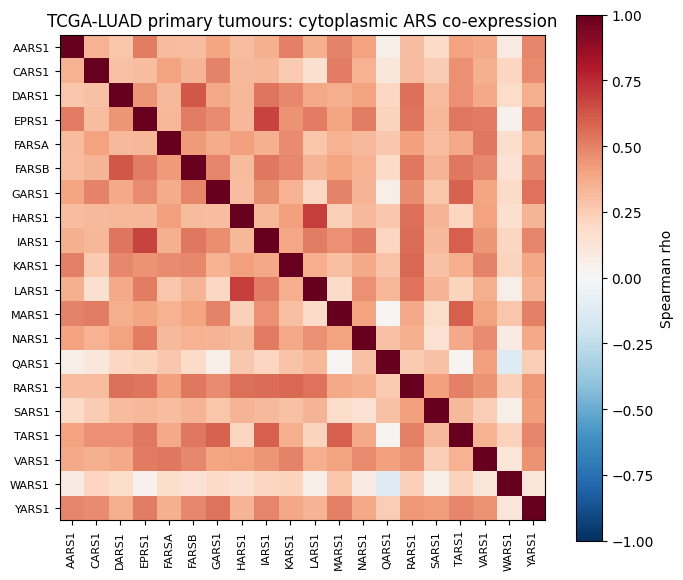

In [15]:
# 10A. HEATMAP of pairwise Spearman correlations (cytoplasmic ARS)
corr = pd.DataFrame(np.corrcoef(ranks.loc[ars].values), index=ars, columns=ars)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ars))); ax.set_xticklabels(ars, rotation=90, fontsize=8)
ax.set_yticks(range(len(ars))); ax.set_yticklabels(ars, fontsize=8)
fig.colorbar(im, ax=ax, label="Spearman rho")
ax.set_title("TCGA-LUAD primary tumours: cytoplasmic ARS co-expression")
fig.tight_layout()
fig.savefig(FIG_DIR/"fig1_ars_cyto_correlation_heatmap.png", dpi=200)
plt.show()

corr.to_csv(RES_DIR/"ars_cyto_spearman_matrix.tsv", sep="\t")

## 11. Question 2 — Does the co-expression survive proliferation adjustment?

**Idea:** if ARS genes correlate only because proliferating tumours express all translation genes more, the correlation should drop strongly after we remove the proliferation signal.

**Method (linear residuals):**
1. Proliferation score = mean z-score of the proliferation markers in each tumour.
2. For every gene, fit `rank(gene) ~ proliferation score` by linear regression and keep the **residuals** (the part of the gene's variation that proliferation does not explain).
3. Repeat Question 1 on the residuals, including a new null distribution.

In [16]:
# 11. PROLIFERATION ADJUSTMENT
def signature_score(found_dict, data=X):
    genes = [v for v in found_dict.values() if v in data.index]
    z = data.loc[genes].sub(data.loc[genes].mean(axis=1), axis=0).div(data.loc[genes].std(axis=1), axis=0)
    return z.mean(axis=0)

prolif = signature_score(FOUND["Proliferation"]).loc[ranks.columns]

# Residuals of every expressed gene after regressing on the proliferation score (vectorised least squares)
P = np.column_stack([np.ones(len(prolif)), prolif.values])
beta, *_ = np.linalg.lstsq(P, ranks.values.T, rcond=None)
resid = pd.DataFrame((ranks.values.T - P @ beta).T, index=ranks.index, columns=ranks.columns)

obs_adj = median_pairwise_rho(ars, resid)
null_adj = null_distribution(ars, resid)
p_adj = (np.sum(null_adj >= obs_adj) + 1) / (N_PERM + 1)

print(f"Median rho BEFORE adjustment: {obs_raw:.3f} (p = {p_raw:.4f})")
print(f"Median rho AFTER  adjustment: {obs_adj:.3f} (p = {p_adj:.4f})")
print(f"Fraction of the signal remaining: {obs_adj/obs_raw:.0%}" if obs_raw > 0 else "Raw correlation was not positive.")

Median rho BEFORE adjustment: 0.358 (p = 0.0010)
Median rho AFTER  adjustment: 0.261 (p = 0.0010)
Fraction of the signal remaining: 73%


### 11A. Observed value versus random expectation
The histograms show the random gene set distributions; the vertical line marks the ARS gene set. A line far to the right of the histogram means the ARS signal is stronger than expected by chance.

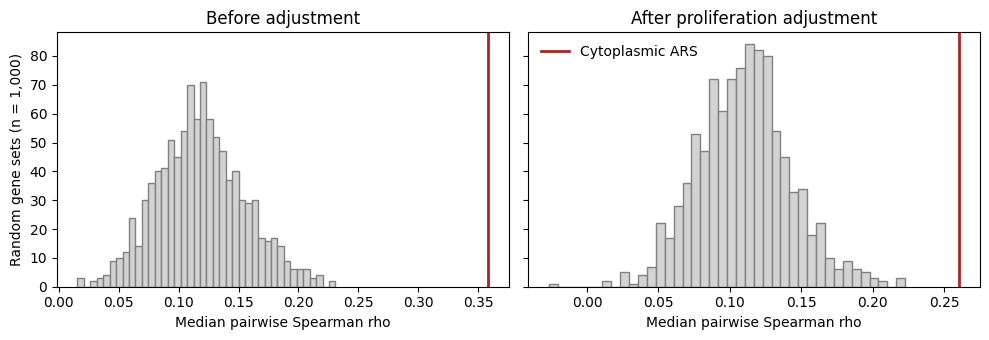

In [17]:
# 11A. NULL DISTRIBUTION PLOTS (before and after proliferation adjustment)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, null, obs, title in [(axes[0], null_raw, obs_raw, "Before adjustment"),
                             (axes[1], null_adj, obs_adj, "After proliferation adjustment")]:
    ax.hist(null, bins=40, color="lightgrey", edgecolor="grey")
    ax.axvline(obs, color="firebrick", lw=2, label="Cytoplasmic ARS")
    ax.set_title(title); ax.set_xlabel("Median pairwise Spearman rho")
axes[0].set_ylabel("Random gene sets (n = 1,000)")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig2_null_distributions.png", dpi=200)
plt.show()

## 12. Question 3 — Is the ARS module linked to ATF4 activity?

* **ARS module score** = mean z-score of the cytoplasmic ARS genes in each tumour.
* **ATF4 score** = mean z-score of the non-ARS ATF4 targets (Step 5).

We report the Spearman correlation between the two scores **before** and **after** removing the proliferation score from both. The mitochondrial ARS module is reported next to it as an internal comparison: if ATF4 mainly drives the cytoplasmic genes, the mitochondrial correlation should be weaker.

In [18]:
# 12. ATF4 ASSOCIATION
def spearman(a, b):
    return np.corrcoef(a.rank(), b.rank())[0, 1]

def remove_prolif(score):
    Pm = np.column_stack([np.ones(len(prolif)), prolif.values])
    b, *_ = np.linalg.lstsq(Pm, score.values, rcond=None)
    return pd.Series(score.values - Pm @ b, index=score.index)

atf4 = signature_score(FOUND["ATF4"]).loc[ranks.columns]
rows = []
for module in ["ARS_cyto", "ARS_mito"]:
    s = signature_score(FOUND[module]).loc[ranks.columns]
    rows.append({"module": module,
                 "rho_vs_ATF4_raw": round(spearman(s, atf4), 3),
                 "rho_vs_ATF4_prolif_adjusted": round(spearman(remove_prolif(s), remove_prolif(atf4)), 3),
                 "rho_vs_proliferation": round(spearman(s, prolif), 3)})

atf4_table = pd.DataFrame(rows)
display(atf4_table)
atf4_table.to_csv(RES_DIR/"module_vs_atf4.tsv", sep="\t", index=False)

,module,rho_vs_ATF4_raw,rho_vs_ATF4_prolif_adjusted,rho_vs_proliferation
0,ARS_cyto,0.518,0.311,0.628
1,ARS_mito,0.316,0.131,0.444


# PART VI: Pilot summary and decision

## 13. Summary table
All key numbers of the pilot are written to one table. This file goes to the GitHub repository and is the evidence behind the decision.

In [19]:
# 13. SUMMARY TABLE
summary = pd.DataFrame([
    ["cohort", "TCGA-LUAD primary tumours"],
    ["n_tumours", X.shape[1]],
    ["n_cytoplasmic_ARS_tested", len(ars)],
    ["median_rho_raw", round(obs_raw, 3)],
    ["null_95th_percentile_raw", round(float(np.percentile(null_raw, 95)), 3)],
    ["empirical_p_raw", round(p_raw, 4)],
    ["median_rho_prolif_adjusted", round(obs_adj, 3)],
    ["null_95th_percentile_adjusted", round(float(np.percentile(null_adj, 95)), 3)],
    ["empirical_p_adjusted", round(p_adj, 4)],
    ["rho_ARS_cyto_vs_ATF4_adjusted", atf4_table.loc[0, "rho_vs_ATF4_prolif_adjusted"]],
    ["rho_ARS_mito_vs_ATF4_adjusted", atf4_table.loc[1, "rho_vs_ATF4_prolif_adjusted"]],
], columns=["metric", "value"])
display(summary)
summary.to_csv(RES_DIR/"pilot_summary.tsv", sep="\t", index=False)

,metric,value
0,cohort,TCGA-LUAD primary tumours
1,n_tumours,516
2,n_cytoplasmic_ARS_tested,20
3,median_rho_raw,0.358
4,null_95th_percentile_raw,0.182
5,empirical_p_raw,0.001
6,median_rho_prolif_adjusted,0.261
7,null_95th_percentile_adjusted,0.164
8,empirical_p_adjusted,0.001
9,rho_ARS_cyto_vs_ATF4_adjusted,0.311


## 14. Decision rule
The decision rule was written **before** looking at the results, so the pilot cannot be interpreted to fit our hopes.

| Pilot result | Decision |
| --- | --- |
| A. ARS co-expression above random (p < 0.05) **and** still above random after proliferation adjustment | Continue with the full plan (pan-cancer + ATF4 + chromatin) |
| B. Above random before adjustment, **not** after adjustment | Reframe: "ARS expression mainly tracks proliferation"; search for cancer types or subgroups where ATF4 adds explanation |
| C. Not above random even before adjustment | Stop this question; move to candidate 2 (mitochondrial vs cytoplasmic) or 3 (isoforms) |

The cell below applies the rule automatically. The ATF4 result is reported but does not change the category: one cancer type is too few to judge a regulatory link.

In [20]:
# 14. DECISION
if p_raw < 0.05 and p_adj < 0.05:
    decision = "A - Continue with the full plan."
elif p_raw < 0.05:
    decision = "B - Reframe around proliferation; look for ATF4-specific subgroups."
else:
    decision = "C - Move to an alternative question."

print("PILOT DECISION:", decision)
print(f"ATF4 link of the cytoplasmic module after adjustment: rho = {atf4_table.loc[0, 'rho_vs_ATF4_prolif_adjusted']}")
print(f"ATF4 link of the mitochondrial module after adjustment: rho = {atf4_table.loc[1, 'rho_vs_ATF4_prolif_adjusted']}")
(RES_DIR/"pilot_decision.txt").write_text(decision + "\n")

PILOT DECISION: A - Continue with the full plan.
ATF4 link of the cytoplasmic module after adjustment: rho = 0.311
ATF4 link of the mitochondrial module after adjustment: rho = 0.131


33

## 15. Copying the outputs to Google Drive
Colab's `/content` area is temporary. Results, figures and logs are copied to Drive. The downloaded data are **not** copied, because they can be downloaded again from the URLs in the input manifest.

In [21]:
# 15. PERMANENT STORAGE: results, figures and logs -> Google Drive
EXPORT_DIR = Path("/content/drive/MyDrive/ARS_project/01_feasibility_pilot")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
for folder in (RES_DIR, FIG_DIR, LOG_DIR):
    shutil.copytree(folder, EXPORT_DIR/folder.name, dirs_exist_ok=True)
print("Outputs copied to:", EXPORT_DIR)

Outputs copied to: /content/drive/MyDrive/ARS_project/01_feasibility_pilot


## 16. What to report when something goes wrong
If a cell fails, write down the following before asking for help:

```text
Notebook version:
Step number of the failing cell:
Full error message:
Last step that ran successfully:
Shape of the expression matrix (Step 8):
Genes reported as missing (Step 8B):
```

## Limitations of this pilot
* One cancer type only; LUAD results may not generalise.
* TPM-based correlations; no batch or tumour purity correction yet.
* Provisional proliferation and ATF4 marker lists (to be replaced by published gene sets).
* Correlation does not show regulation. Mechanistic support comes later from ATAC-seq, ATF4 ChIP-seq and an independent validation cohort.